Se tienen 10 puntos de referencia.
[INFO] Video generado: data/simulation_output.mp4 (fps=20.00, duración=34.40s)


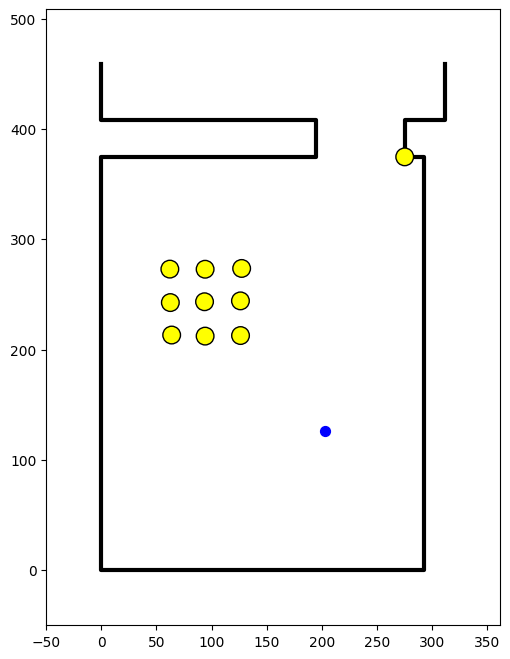

In [ ]:
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from matplotlib.animation import FFMpegWriter
from typing import Any
import cv2

from cvio.homography import Homography

points_real = np.array([
    [275, 375],  # p1
    [62.5, 273], # p2
    [(126.5+62.6)/2, 273],  # p3
    [126.5, 273], # p4
    [62.5, (273+213)/2], # p5
    [(126.5+62.6)/2, (273+213)/2], # p6
    [126.5, (273+213)/2], # p7
    [62.5, 213], # p8
    [(126.5+62.6)/2, 213], # p9
    [126.5, 213], # p10
], dtype=np.float32)

outline = [
    [0, 375 + 33.5 + 50],
    [0, 375 + 33.5],
    [195, 375 + 33.5],
    [195, 375],
    [0, 375],
    [0, 0],
    [293, 0],
    [293, 375],
    [293 - 18, 375],
    [293 - 18, 375 + 33.5],
    [293 + 18.5, 375 + 33.5],
    [293 + 18.5, 375 + 33.5 + 50]
]
outline_arr = np.array(outline, dtype=np.float32)


def load_record(path_json: Path) -> tuple[list[tuple[float, float]], list[list[dict[str, Any]]]]:
    with open(path_json, "r") as f:
        data = json.load(f)

    points_ref = [tuple(p) for p in data["points_ref_list"]]
    print(f"Se tienen {len(points_ref)} puntos de referencia.")

    for boxes_json in data["boxes_json_list"]:
        for box in boxes_json:
            cx = (box["x1"] + box["x2"]) / 2
            cy = box["y2"] - (box["y2"] - box["y1"]) / 10
            box["cx"] = cx
            box["cy"] = cy
    return points_ref, data["boxes_json_list"]


def draw_room_outline(ax: plt.Axes) -> None:
    xs, ys = zip(*outline)
    ax.plot(xs, ys, color="black", linewidth=3)


def get_video_duration(path: Path) -> float:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise IOError(f"No se pudo abrir el video: {path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps
    cap.release()
    return duration


def create_simulation_animation(json_path: Path, original_video_path: Path, output_path: Path) -> None:
    points_ref, boxes_all = load_record(json_path)

    points_ref_np = np.array(points_ref, dtype=np.float32)
    homography = Homography(points_real=points_real, points_ref=points_ref_np)

    projected_refs = homography.project_points(points=np.array(points_ref, dtype=np.float32))

    projected_boxes_all = []
    for boxes in boxes_all:
        pts = np.array([[b["cx"], b["cy"]] for b in boxes], dtype=np.float32)
        if pts.shape[0] != 0:
            projected_pts = homography.project_points(points=pts)
            for b, (x, y) in zip(boxes, projected_pts):
                b["cx_proj"] = x
                b["cy_proj"] = y
            projected_boxes_all.append(boxes)

    all_x = np.append(outline_arr[:, 0], projected_refs[:, 0])
    all_y = np.append(outline_arr[:, 1], projected_refs[:, 1])
    padding = 50
    min_x, max_x = np.min(all_x), np.max(all_x)
    min_y, max_y = np.min(all_y), np.max(all_y)

    fig, ax = plt.subplots(figsize=(8, 8))
    draw_room_outline(ax)
    ax.set_aspect("equal")
    ax.set_xlim(min_x - padding, max_x + padding)
    ax.set_ylim(min_y - padding, max_y + padding)

    for x, y in projected_refs:
        circ = Circle((x, y), radius=8, color="yellow", ec="black", zorder=10)
        ax.add_patch(circ)

    scatters = ax.scatter([], [], s=50, color="blue", zorder=5)

    def update(frame_idx: int):
        boxes = projected_boxes_all[frame_idx]
        xs = [b["cx_proj"] for b in boxes]
        ys = [b["cy_proj"] for b in boxes]
        scatters.set_offsets(list(zip(xs, ys)))
        return scatters,

    # Ajustar FPS a la duración real del video original
    original_duration = get_video_duration(original_video_path)
    total_frames = len(projected_boxes_all)
    fps = total_frames / original_duration

    ani = animation.FuncAnimation(
        fig, update, frames=total_frames, interval=1000 / fps, blit=True
    )

    writer = FFMpegWriter(fps=fps)
    ani.save(output_path, writer=writer)
    print(f"[INFO] Video generado: {output_path} (fps={fps:.2f}, duración={original_duration:.2f}s)")


if __name__ == "__main__":
    DATE = "20250412T130810Z"
    json_path = Path(f"data/{DATE}.json")
    original_video_path = Path(f"data/{DATE}.mp4")
    output_path = Path(f"data/{DATE}.mp4")
    create_simulation_animation(json_path, original_video_path, output_path)
